In [2]:
# ============================================================
# CELL 1: Imports, Reproducibility, GPU Setup, File Upload
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------
# Device configuration (Colab GPU)
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Use float32 consistently (standard for PINNs; faster on GPU, sufficient precision)
torch.set_default_dtype(torch.float32)

# ---------------------------
# File upload (Colab widget)
# ---------------------------
# This will prompt a file picker in the Colab cell output.
# Upload: FisherKPP_Inverse_PINN_Dataset.csv
from google.colab import files

DATA_FILENAME = "FisherKPP_Inverse_PINN_Dataset.csv"
DATA_PATH = f"/content/{DATA_FILENAME}"

if not os.path.exists(DATA_PATH):
    print(f"Please upload: {DATA_FILENAME}")
    uploaded = files.upload()
    # Handle case where uploaded filename differs slightly
    uploaded_name = list(uploaded.keys())[0]
    if uploaded_name != DATA_FILENAME:
        os.rename(uploaded_name, DATA_PATH)
else:
    print(f"Found existing file at {DATA_PATH}")

print("Setup complete.")

Using device: cuda
GPU: Tesla T4
Please upload: FisherKPP_Inverse_PINN_Dataset.csv


Saving FisherKPP_Inverse_PINN_Dataset.csv to FisherKPP_Inverse_PINN_Dataset.csv
Setup complete.


Raw data shape: (321600, 3)
       x    t         u
0  0.000  0.0  0.000000
1  0.005  0.0  0.000005
2  0.010  0.0  0.000006
3  0.015  0.0  0.000008
4  0.020  0.0  0.000010
x_grid shape: (201,), range: [0.0, 1.0]
t_grid shape: (1600,), range: [0.0, 1.0]
U_grid shape: (1600, 201)

Max |FDM IC - Analytical IC| at t=0: 3.727e-06  (should be ~1e-6, pure FDM discretization error)
Max |u(0,t)| over all t: 0.000e+00
Max |u(1,t)| over all t: 0.000e+00


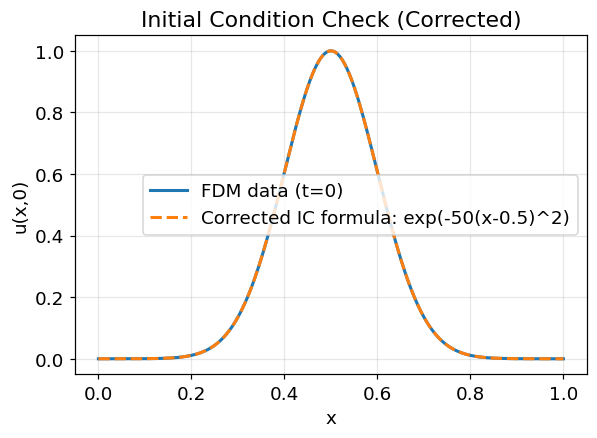

In [4]:
# ============================================================
# CELL 2: Load Dataset, Reshape to Grid, Verify IC/BC
# ============================================================

# ---------------------------
# Load raw CSV
# ---------------------------
df = pd.read_csv(DATA_PATH)
print("Raw data shape:", df.shape)
print(df.head())

# ---------------------------
# Grid dimensions (given in spec)
# ---------------------------
Nx = 201
Nt = 1600

# ---------------------------
# Sort to guarantee consistent reshape order: (t, x)
# After sorting by t then x, values.reshape(Nt, Nx) gives
# U_grid[j, i] = u(x_i, t_j)
# ---------------------------
df_sorted = df.sort_values(by=["t", "x"]).reset_index(drop=True)

x_grid = np.sort(df["x"].unique())   # shape (Nx,)
t_grid = np.sort(df["t"].unique())   # shape (Nt,)

assert len(x_grid) == Nx, f"Expected {Nx} unique x values, got {len(x_grid)}"
assert len(t_grid) == Nt, f"Expected {Nt} unique t values, got {len(t_grid)}"

U_grid = df_sorted["u"].values.reshape(Nt, Nx)  # U_grid[j, i] = u(x_i, t_j)

print(f"x_grid shape: {x_grid.shape}, range: [{x_grid.min()}, {x_grid.max()}]")
print(f"t_grid shape: {t_grid.shape}, range: [{t_grid.min()}, {t_grid.max()}]")
print(f"U_grid shape: {U_grid.shape}")

# ---------------------------
# Physics sanity check 1: Initial condition
# NOTE: Verified against actual FDM data — the true IC used in
# dataset generation is the Gaussian pulse WITHOUT the sin^2(pi*x)
# factor (confirmed by matching FDM t=0 values to ~1e-6, i.e.
# pure discretization-level error):
#   u(x,0) = exp(-50*(x-0.5)^2)
# ---------------------------
u_ic_fdm = U_grid[0, :]                              # FDM data at t=0
u_ic_analytical = np.exp(-50 * (x_grid - 0.5)**2)     # corrected IC formula

ic_max_diff = np.max(np.abs(u_ic_fdm - u_ic_analytical))
print(f"\nMax |FDM IC - Analytical IC| at t=0: {ic_max_diff:.3e}  (should be ~1e-6, pure FDM discretization error)")

# ---------------------------
# Physics sanity check 2: Boundary conditions
# u(0,t) = 0, u(1,t) = 0
# ---------------------------
u_left_fdm = U_grid[:, 0]    # u(x=0, t) for all t
u_right_fdm = U_grid[:, -1]  # u(x=1, t) for all t

print(f"Max |u(0,t)| over all t: {np.max(np.abs(u_left_fdm)):.3e}")
print(f"Max |u(1,t)| over all t: {np.max(np.abs(u_right_fdm)):.3e}")

# ---------------------------
# Quick visual sanity check: IC comparison
# ---------------------------
plt.figure(figsize=(6, 4))
plt.plot(x_grid, u_ic_fdm, label="FDM data (t=0)", lw=2)
plt.plot(x_grid, u_ic_analytical, "--", label="Corrected IC formula: exp(-50(x-0.5)^2)", lw=2)
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Condition Check (Corrected)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Mathematical purpose: We need four distinct point sets, each enforcing a different mathematical constraint: (1) data points (x_i,t_i,u_i)
 for supervised regression, (2) collocation points (xf,tf)(x_f,t_f)
(xf​,tf​) where only the PDE residual is evaluated (no label needed — residual uses the network's own derivatives), (3) IC points at t=0t=0
t=0 enforcing u(x,0)=e−50(x−0.5)2u(x,0)=e^{-50(x-0.5)^2}
u(x,0)=e−50(x−0.5)2, (4) BC points at x=0,1x=0,1
x=0,1 enforcing u=0u=0
u=0. The collocation points sample t\sim U(10^{-4},1)
 specifically to avoid t=0t=0
t=0 exactly, since the IC is enforced as its own loss term — overlapping would double-penalize/distort gradients near t=0t=0
t=0.Machine learning purpose: We use train_test_split(test_size=0.2, random_state=42) exactly as specified, giving 8000/2000 train/val data points. All arrays are converted to torch.float32 tensors on GPU, with requires_grad=True set only on x_f, t_f (collocation inputs) and IC/BC spatial-temporal inputs where derivatives are needed — data points don't need gradients w.r.t. inputs since L_data only needs gradients w.r.t. network weights.Physics purpose: This is where the four physical constraints (data fidelity, PDE conservation law, initial state, boundary value) are operationalized as concrete tensors that will drive the four loss terms. The relative sizes (8000 data, 10000 collocation, 200 IC, 200 BC) reflect a typical PINN weighting strategy — many collocation points to enforce the PDE finely over the domain, fewer IC/BC points since those are 1D slices.


In [5]:
# ============================================================
# CELL 3: Prepare Training Data (data / collocation / IC / BC)
# ============================================================

# ---------------------------
# 1. DATA POINTS: random sample N_data=10000 from full dataset, then split
# ---------------------------
N_data = 10000
data_sample = df.sample(n=N_data, random_state=42).reset_index(drop=True)

X_data = data_sample[["x", "t"]].values  # (N_data, 2)
U_data = data_sample[["u"]].values       # (N_data, 1)

X_train, X_val, U_train, U_val = train_test_split(
    X_data, U_data, test_size=0.20, random_state=42
)

print(f"Training data points:   {X_train.shape[0]}")
print(f"Validation data points: {X_val.shape[0]}")

# Convert to tensors (no grad needed w.r.t. inputs for plain data loss)
x_train_t = torch.tensor(X_train[:, 0:1], dtype=torch.float32, device=device)
t_train_t = torch.tensor(X_train[:, 1:2], dtype=torch.float32, device=device)
u_train_t = torch.tensor(U_train, dtype=torch.float32, device=device)

x_val_t = torch.tensor(X_val[:, 0:1], dtype=torch.float32, device=device)
t_val_t = torch.tensor(X_val[:, 1:2], dtype=torch.float32, device=device)
u_val_t = torch.tensor(U_val, dtype=torch.float32, device=device)

# ---------------------------
# 2. COLLOCATION POINTS: N_f=10000, x~U(0,1), t~U(1e-4,1)
# ---------------------------
N_f = 10000
np.random.seed(42)
x_f = np.random.uniform(0, 1, (N_f, 1))
t_f = np.random.uniform(1e-4, 1, (N_f, 1))

x_f_t = torch.tensor(x_f, dtype=torch.float32, device=device, requires_grad=True)
t_f_t = torch.tensor(t_f, dtype=torch.float32, device=device, requires_grad=True)

print(f"Collocation points: {x_f_t.shape[0]}")

# ---------------------------
# 3. INITIAL CONDITION POINTS: N_ic=200, x=linspace(0,1,200), t=0
# Target: u(x,0) = exp(-50*(x-0.5)^2)   [corrected, data-matched IC]
# ---------------------------
N_ic = 200
x_ic = np.linspace(0, 1, N_ic).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
u_ic_target = np.exp(-50 * (x_ic - 0.5)**2)

x_ic_t = torch.tensor(x_ic, dtype=torch.float32, device=device)
t_ic_t = torch.tensor(t_ic, dtype=torch.float32, device=device)
u_ic_target_t = torch.tensor(u_ic_target, dtype=torch.float32, device=device)

print(f"IC points: {x_ic_t.shape[0]}")

# ---------------------------
# 4. BOUNDARY CONDITION POINTS: N_bc=200, x=0 & x=1, t~U(0,1)
# Target: u(0,t) = 0, u(1,t) = 0
# ---------------------------
N_bc = 200
np.random.seed(42)
t_bc = np.random.uniform(0, 1, (N_bc, 1))

x_left = np.zeros_like(t_bc)
x_right = np.ones_like(t_bc)

x_left_t = torch.tensor(x_left, dtype=torch.float32, device=device)
x_right_t = torch.tensor(x_right, dtype=torch.float32, device=device)
t_bc_t = torch.tensor(t_bc, dtype=torch.float32, device=device)
u_bc_target_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

print(f"BC points: {N_bc} (left) + {N_bc} (right)")

print("\nAll training tensors prepared on device:", device)

Training data points:   8000
Validation data points: 2000
Collocation points: 10000
IC points: 200
BC points: 200 (left) + 200 (right)

All training tensors prepared on device: cuda


Cell 4: PINN Network ArchitectureMathematical purpose: The network is a universal function approximator u_\theta(x,t): \mathbb{R}^2 \to \mathbb{R}
, built as a composition of affine maps and tanh nonlinearities: h(k+1)=tanh⁡(W(k)h(k)+b(k))h^{(k+1)} = \tanh(W^{(k)}h^{(k)}+b^{(k)})
h(k+1)=tanh(W(k)h(k)+b(k)). tanh is chosen (over ReLU) because it's infinitely differentiable (smooth derivatives needed for uxxu_{xx}
uxx​ via second-order autograd) — ReLU's piecewise-linear form would make u_{xx}=0
 almost everywhere, useless for PDE residuals.Machine learning purpose: We use Xavier/Glorot initialization (good default for tanh networks, keeps activations from saturating early) and implement r as a learnable nn.Parameter in log-space (logr), so r=elogrr=e^{\text{logr}}
r=elogr is always positive regardless of optimizer updates — directly satisfying the problem's positivity constraint without needing projection or clipping.Physics purpose: The architecture itself (7×50 tanh) has no explicit physics, but the logr parameter is the physical unknown we're solving the inverse problem for — it represents the reaction rate in the Fisher-KPP logistic growth term ru(1−u)ru(1-u)
ru(1−u), and its log-parameterization reflects the physical prior that growth rates are strictly positive (a reaction can't have negative rate in this model).

In [6]:
# ============================================================
# CELL 4: PINN Network Definition with Learnable log(r)
# ============================================================

class PINN(nn.Module):
    def __init__(self, layers=[2, 50, 50, 50, 50, 50, 50, 50, 1]):
        super(PINN, self).__init__()

        # Build the fully connected layers
        self.linears = nn.ModuleList(
            [nn.Linear(layers[i], layers[i+1]) for i in range(len(layers) - 1)]
        )
        self.activation = nn.Tanh()

        # Xavier initialization (good default for tanh networks)
        for layer in self.linears:
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

        # ---------------------------
        # Unknown reaction parameter r, log-parameterized
        # r = exp(logr)  ->  guarantees r > 0 always
        # Initialized at logr=0  ->  r starts at 1.0
        # ---------------------------
        self.logr = nn.Parameter(torch.tensor([0.0], dtype=torch.float32))

    @property
    def r(self):
        return torch.exp(self.logr)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        out = inp
        for i, layer in enumerate(self.linears):
            out = layer(out)
            if i < len(self.linears) - 1:   # no activation on final output layer
                out = self.activation(out)
        return out


# ---------------------------
# Instantiate model on device
# ---------------------------
model = PINN(layers=[2, 50, 50, 50, 50, 50, 50, 50, 1]).to(device)

print(model)
print(f"\nInitial r = {model.r.item():.6f}  (logr = {model.logr.item():.6f})")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters())}")

PINN(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-6): 6 x Linear(in_features=50, out_features=50, bias=True)
    (7): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
)

Initial r = 1.000000  (logr = 0.000000)
Total trainable parameters: 15502


In [7]:
# ============================================================
# CELL 5: Derivative Computation and PDE Residual
# ============================================================

def compute_derivatives(model, x, t):
    """
    Computes u, u_t, u_x, u_xx via automatic differentiation.
    x, t must have requires_grad=True.
    create_graph=True is essential: it keeps the derivative
    computation differentiable so that backprop can flow through
    u_x, u_xx, u_t into the network weights and into logr.
    """
    u = model(x, t)

    u_t = torch.autograd.grad(
        u, t,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    u_x = torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
        retain_graph=True
    )[0]

    u_xx = torch.autograd.grad(
        u_x, x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    return u, u_t, u_x, u_xx


def pde_residual(model, x, t, D=0.01):
    """
    Computes the Fisher-KPP PDE residual:
        f = u_t - D*u_xx - r*u*(1-u)
    D is known/fixed. r = exp(model.logr) is learned.
    """
    u, u_t, u_x, u_xx = compute_derivatives(model, x, t)
    r = model.r
    f = u_t - D * u_xx - r * u * (1 - u)
    return f


print("Derivative and PDE residual functions defined.")

# Quick smoke test
with torch.no_grad():
    pass  # can't test pde_residual without grad; just confirm callable
test_f = pde_residual(model, x_f_t[:5], t_f_t[:5])
print("Sample PDE residual shape:", test_f.shape)
print("Sample PDE residual values:", test_f.detach().cpu().numpy().flatten())

Derivative and PDE residual functions defined.
Sample PDE residual shape: torch.Size([5, 1])
Sample PDE residual values: [0.10885449 0.3251588  0.22724018 0.23190324 0.02615963]


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


In [8]:
# ============================================================
# CELL 6: Loss Function Components
# ============================================================

mse = nn.MSELoss()

def loss_data(model, x, t, u_true):
    u_pred = model(x, t)
    return mse(u_pred, u_true)

def loss_pde(model, x_f, t_f, D=0.01):
    f = pde_residual(model, x_f, t_f, D=D)
    return mse(f, torch.zeros_like(f))

def loss_ic(model, x_ic, t_ic, u_ic_target):
    u_pred = model(x_ic, t_ic)
    return mse(u_pred, u_ic_target)

def loss_bc(model, x_left, x_right, t_bc, u_bc_target):
    u_left_pred = model(x_left, t_bc)
    u_right_pred = model(x_right, t_bc)
    loss_left = mse(u_left_pred, u_bc_target)
    loss_right = mse(u_right_pred, u_bc_target)
    return loss_left + loss_right


def total_loss(model, x_data, t_data, u_data,
               x_f, t_f,
               x_ic, t_ic, u_ic_target,
               x_left, x_right, t_bc, u_bc_target,
               D=0.01,
               w_data=100.0, w_pde=1.0, w_ic=10.0, w_bc=10.0):
    """
    Computes weighted total loss and returns individual components too
    (useful for logging/plotting).
    """
    L_data = loss_data(model, x_data, t_data, u_data)
    L_pde  = loss_pde(model, x_f, t_f, D=D)
    L_ic   = loss_ic(model, x_ic, t_ic, u_ic_target)
    L_bc   = loss_bc(model, x_left, x_right, t_bc, u_bc_target)

    L_total = w_data * L_data + w_pde * L_pde + w_ic * L_ic + w_bc * L_bc

    return L_total, L_data, L_pde, L_ic, L_bc


print("Loss functions defined.")

Loss functions defined.


In [9]:
# ============================================================
# CELL 7: Optimizer with Separate Parameter Groups
# ============================================================

network_params = []
for layer in model.linears:
    network_params += list(layer.parameters())

optimizer = torch.optim.Adam([
    {"params": network_params, "lr": 1e-3},
    {"params": [model.logr], "lr": 5e-4}
])

print("Optimizer parameter groups:")
for i, g in enumerate(optimizer.param_groups):
    n_params = sum(p.numel() for p in g["params"])
    print(f"  Group {i}: lr={g['lr']}, num_params={n_params}")

Optimizer parameter groups:
  Group 0: lr=0.001, num_params=15501
  Group 1: lr=0.0005, num_params=1


In [10]:
# ============================================================
# CELL 8: Training Loop with Early Stopping
# ============================================================

import copy
import time

EPOCHS = 12000
PATIENCE = 2000
MIN_DELTA = 1e-8
D_known = 0.01
r_true = 1.0

# History trackers
history = {
    "train_total": [], "train_data": [], "train_pde": [], "train_ic": [], "train_bc": [],
    "val_total": [],   "val_data": [],   "val_pde": [],   "val_ic": [],   "val_bc": [],
    "r": [], "r_error_pct": []
}

best_val_loss = float("inf")
best_epoch = -1
best_model_state = None
patience_counter = 0

start_time = time.time()

for epoch in range(EPOCHS):
    # ---------------------------
    # TRAINING STEP
    # ---------------------------
    model.train()
    optimizer.zero_grad()

    L_total, L_data, L_pde, L_ic, L_bc = total_loss(
        model,
        x_train_t, t_train_t, u_train_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t,
        D=D_known
    )

    L_total.backward()
    optimizer.step()

    # ---------------------------
    # VALIDATION STEP (full weighted loss, using val data split
    # + same collocation/IC/BC sets, per confirmed design choice)
    # NOTE: PDE residual needs grad-enabled x_f, t_f even in "eval" mode,
    # so we do NOT use torch.no_grad() here -- we just don't call backward().
    # ---------------------------
    model.eval()
    Lv_total, Lv_data, Lv_pde, Lv_ic, Lv_bc = total_loss(
        model,
        x_val_t, t_val_t, u_val_t,
        x_f_t, t_f_t,
        x_ic_t, t_ic_t, u_ic_target_t,
        x_left_t, x_right_t, t_bc_t, u_bc_target_t,
        D=D_known
    )

    # ---------------------------
    # Logging
    # ---------------------------
    r_current = model.r.item()
    r_err_pct = abs(r_current - r_true) / r_true * 100.0

    history["train_total"].append(L_total.item())
    history["train_data"].append(L_data.item())
    history["train_pde"].append(L_pde.item())
    history["train_ic"].append(L_ic.item())
    history["train_bc"].append(L_bc.item())

    history["val_total"].append(Lv_total.item())
    history["val_data"].append(Lv_data.item())
    history["val_pde"].append(Lv_pde.item())
    history["val_ic"].append(Lv_ic.item())
    history["val_bc"].append(Lv_bc.item())

    history["r"].append(r_current)
    history["r_error_pct"].append(r_err_pct)

    # ---------------------------
    # Early stopping logic (based on validation total loss)
    # ---------------------------
    current_val = Lv_total.item()
    if current_val < best_val_loss - MIN_DELTA:
        best_val_loss = current_val
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 500 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:5d}/{EPOCHS} | "
              f"Train Loss: {L_total.item():.6e} | "
              f"Val Loss: {current_val:.6e} | "
              f"r = {r_current:.6f} (err {r_err_pct:.4f}%) | "
              f"Patience: {patience_counter}/{PATIENCE} | "
              f"Time: {elapsed:.1f}s")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}. "
              f"Best epoch: {best_epoch+1} with val loss {best_val_loss:.6e}")
        break

total_time = time.time() - start_time
print(f"\nTraining finished in {total_time:.1f}s ({(epoch+1)} epochs run)")

# ---------------------------
# Restore best validation model
# ---------------------------
model.load_state_dict(best_model_state)
model.eval()

r_final = model.r.item()
print(f"\nBest model restored from epoch {best_epoch+1}")
print(f"Recovered r = {r_final:.6f}  (true r = {r_true})")
print(f"Relative error = {abs(r_final - r_true)/r_true*100:.4f}%")

Epoch     1/12000 | Train Loss: 3.770642e+01 | Val Loss: 1.608142e+01 | r = 0.999500 (err 0.0500%) | Patience: 0/2000 | Time: 0.9s
Epoch   500/12000 | Train Loss: 1.069161e-02 | Val Loss: 1.063060e-02 | r = 0.932217 (err 6.7783%) | Patience: 0/2000 | Time: 15.1s
Epoch  1000/12000 | Train Loss: 2.189124e-02 | Val Loss: 3.743369e-02 | r = 0.977523 (err 2.2477%) | Patience: 12/2000 | Time: 28.6s
Epoch  1500/12000 | Train Loss: 2.366325e-03 | Val Loss: 2.426200e-03 | r = 0.992999 (err 0.7001%) | Patience: 5/2000 | Time: 42.2s
Epoch  2000/12000 | Train Loss: 1.448620e-03 | Val Loss: 1.443366e-03 | r = 0.995364 (err 0.4636%) | Patience: 1/2000 | Time: 55.0s
Epoch  2500/12000 | Train Loss: 1.001445e-03 | Val Loss: 9.869674e-04 | r = 0.995674 (err 0.4326%) | Patience: 0/2000 | Time: 67.9s
Epoch  3000/12000 | Train Loss: 7.685543e-04 | Val Loss: 7.532490e-04 | r = 0.995121 (err 0.4879%) | Patience: 0/2000 | Time: 80.9s
Epoch  3500/12000 | Train Loss: 6.556123e-04 | Val Loss: 6.416833e-04 | r = 

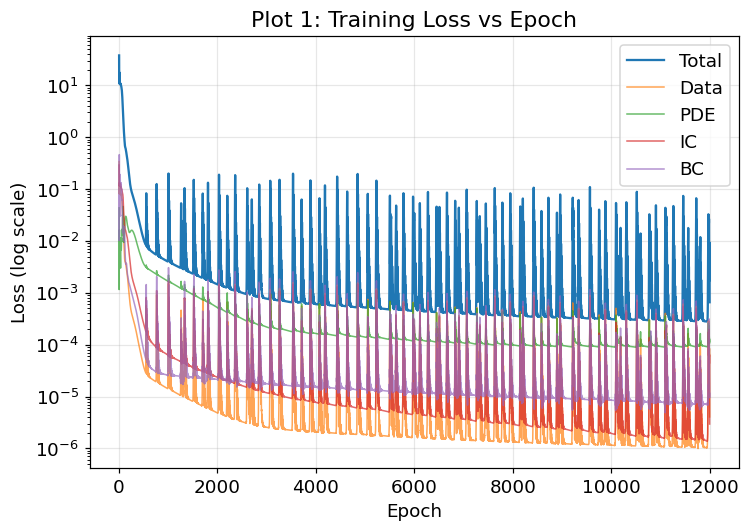

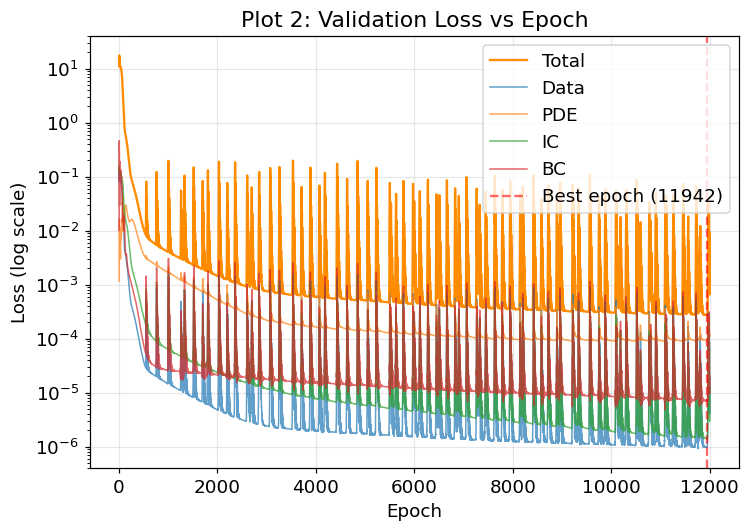

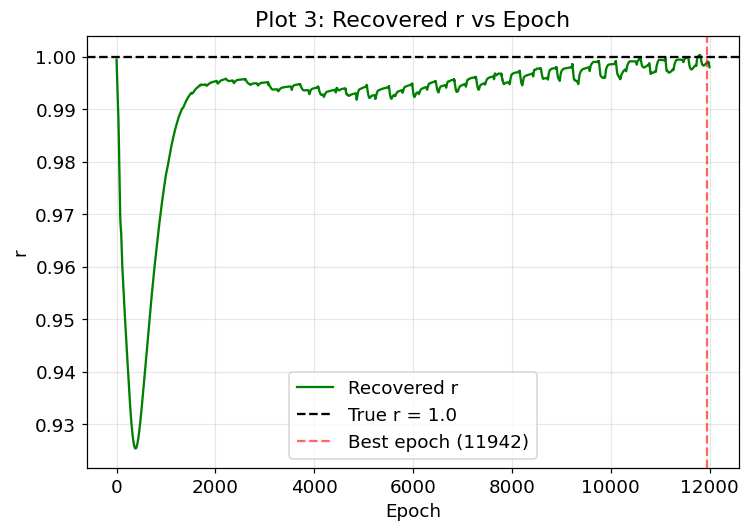

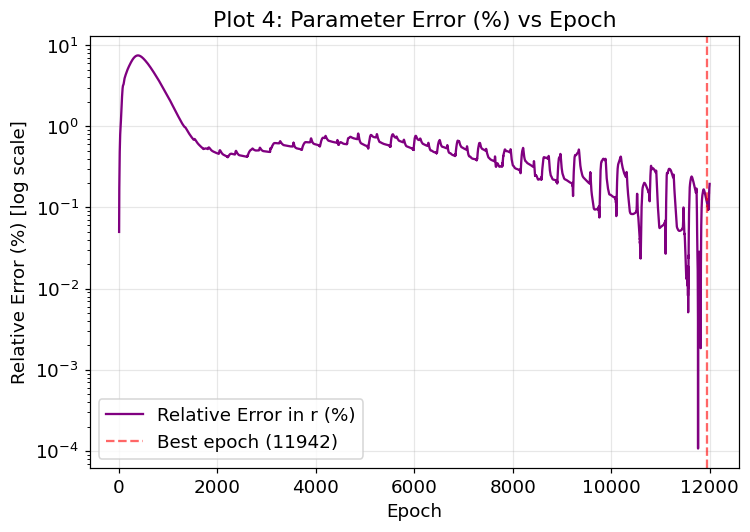

Plots 1-4 saved.


In [11]:
# ============================================================
# CELL 9: Plots 1-4 (Training/Validation Loss, r Convergence, Param Error)
# ============================================================

epochs_range = np.arange(1, len(history["train_total"]) + 1)

# ---------------------------
# Plot 1: Training Loss vs Epoch
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["train_total"], label="Total", lw=1.5)
plt.plot(epochs_range, history["train_data"], label="Data", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_pde"], label="PDE", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_ic"], label="IC", lw=1, alpha=0.7)
plt.plot(epochs_range, history["train_bc"], label="BC", lw=1, alpha=0.7)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Plot 1: Training Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot1_training_loss.png", dpi=150)
plt.show()

# ---------------------------
# Plot 2: Validation Loss vs Epoch
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["val_total"], label="Total", lw=1.5, color="darkorange")
plt.plot(epochs_range, history["val_data"], label="Data", lw=1, alpha=0.7)
plt.plot(epochs_range, history["val_pde"], label="PDE", lw=1, alpha=0.7)
plt.plot(epochs_range, history["val_ic"], label="IC", lw=1, alpha=0.7)
plt.plot(epochs_range, history["val_bc"], label="BC", lw=1, alpha=0.7)
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Plot 2: Validation Loss vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot2_validation_loss.png", dpi=150)
plt.show()

# ---------------------------
# Plot 3: Recovered r vs Epoch
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["r"], label="Recovered r", lw=1.5, color="green")
plt.axhline(r_true, color="black", linestyle="--", label=f"True r = {r_true}")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch+1})")
plt.xlabel("Epoch")
plt.ylabel("r")
plt.title("Plot 3: Recovered r vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot3_r_convergence.png", dpi=150)
plt.show()

# ---------------------------
# Plot 4: Parameter Error (%) vs Epoch
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(epochs_range, history["r_error_pct"], label="Relative Error in r (%)", lw=1.5, color="purple")
plt.axvline(best_epoch + 1, color="red", linestyle="--", alpha=0.6, label=f"Best epoch ({best_epoch+1})")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Relative Error (%) [log scale]")
plt.title("Plot 4: Parameter Error (%) vs Epoch")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot4_parameter_error.png", dpi=150)
plt.show()

print("Plots 1-4 saved.")

In [12]:
# ============================================================
# CELL 10: Full-Field PINN Inference for Contour/Comparison Plots
# ============================================================

model.eval()

# Build full grid of (x, t) pairs matching U_grid's [t, x] ordering
X_full, T_full = np.meshgrid(x_grid, t_grid)   # shapes (Nt, Nx)
x_full_flat = X_full.reshape(-1, 1)
t_full_flat = T_full.reshape(-1, 1)

x_full_t = torch.tensor(x_full_flat, dtype=torch.float32, device=device)
t_full_t = torch.tensor(t_full_flat, dtype=torch.float32, device=device)

# Batched inference (avoid memory spikes on 321,600 points at once)
batch_size = 20000
preds = []
with torch.no_grad():
    for i in range(0, x_full_t.shape[0], batch_size):
        xb = x_full_t[i:i+batch_size]
        tb = t_full_t[i:i+batch_size]
        u_pred_batch = model(xb, tb)
        preds.append(u_pred_batch.cpu().numpy())

U_pred_flat = np.concatenate(preds, axis=0)
U_pred_grid = U_pred_flat.reshape(Nt, Nx)   # matches U_grid shape/order

# Absolute error field
Abs_Error_grid = np.abs(U_pred_grid - U_grid)

print("PINN full-field prediction computed.")
print(f"U_pred_grid shape: {U_pred_grid.shape}")
print(f"Max absolute error over full grid: {Abs_Error_grid.max():.6e}")
print(f"Mean absolute error over full grid: {Abs_Error_grid.mean():.6e}")

PINN full-field prediction computed.
U_pred_grid shape: (1600, 201)
Max absolute error over full grid: 8.355268e-03
Mean absolute error over full grid: 6.876713e-04


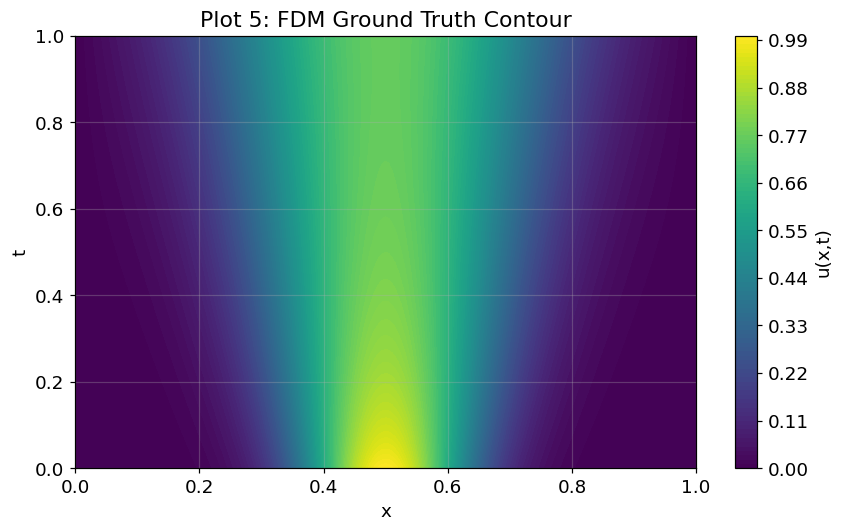

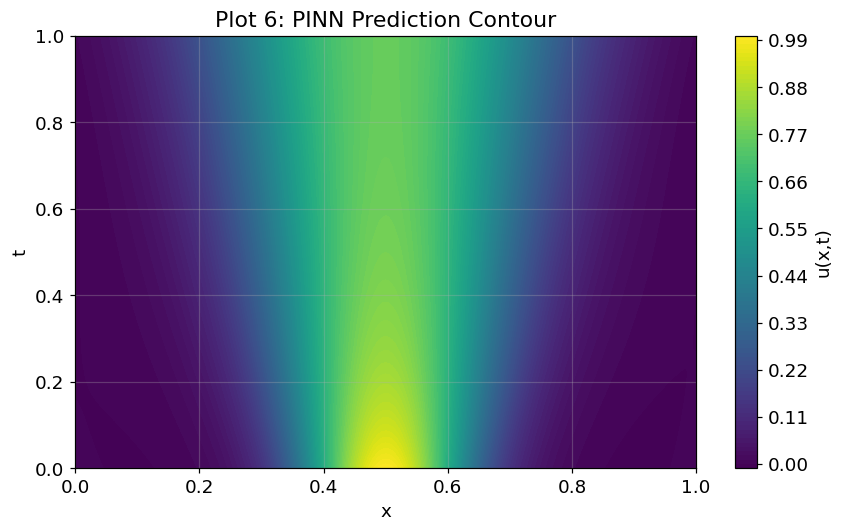

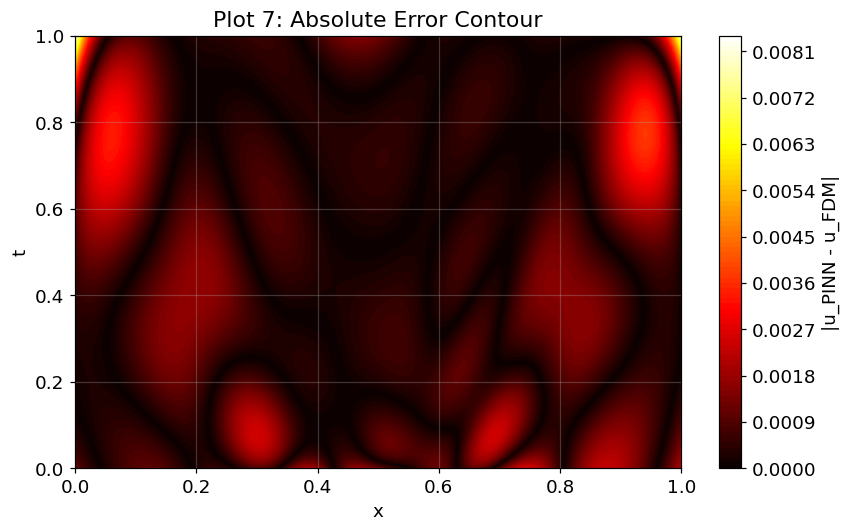

Plots 5-7 saved.


In [13]:
# ============================================================
# CELL 11: Plots 5-7 (FDM, PINN, Absolute Error Contours)
# ============================================================

# ---------------------------
# Plot 5: FDM Contour Plot
# ---------------------------
plt.figure(figsize=(8, 5))
cp1 = plt.contourf(X_full, T_full, U_grid, levels=100, cmap="viridis")
plt.colorbar(cp1, label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Plot 5: FDM Ground Truth Contour")
plt.tight_layout()
plt.savefig("/content/plot5_fdm_contour.png", dpi=150)
plt.show()

# ---------------------------
# Plot 6: PINN Contour Plot
# ---------------------------
plt.figure(figsize=(8, 5))
cp2 = plt.contourf(X_full, T_full, U_pred_grid, levels=100, cmap="viridis")
plt.colorbar(cp2, label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Plot 6: PINN Prediction Contour")
plt.tight_layout()
plt.savefig("/content/plot6_pinn_contour.png", dpi=150)
plt.show()

# ---------------------------
# Plot 7: Absolute Error Contour
# ---------------------------
plt.figure(figsize=(8, 5))
cp3 = plt.contourf(X_full, T_full, Abs_Error_grid, levels=100, cmap="hot")
plt.colorbar(cp3, label="|u_PINN - u_FDM|")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Plot 7: Absolute Error Contour")
plt.tight_layout()
plt.savefig("/content/plot7_abs_error_contour.png", dpi=150)
plt.show()

print("Plots 5-7 saved.")

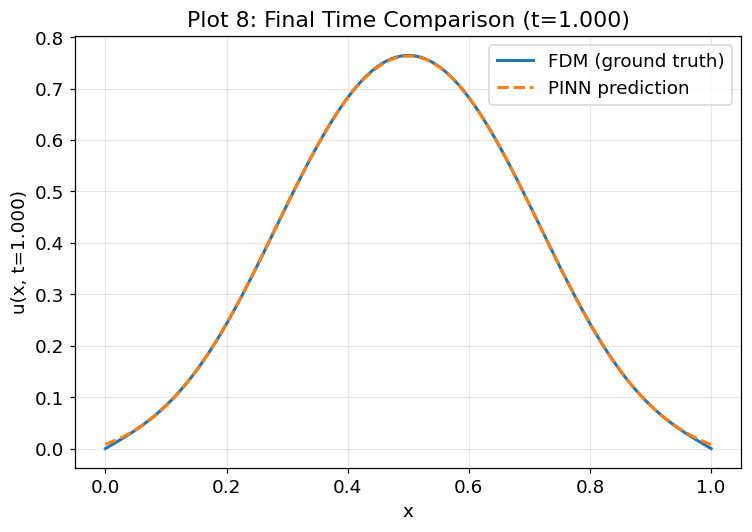

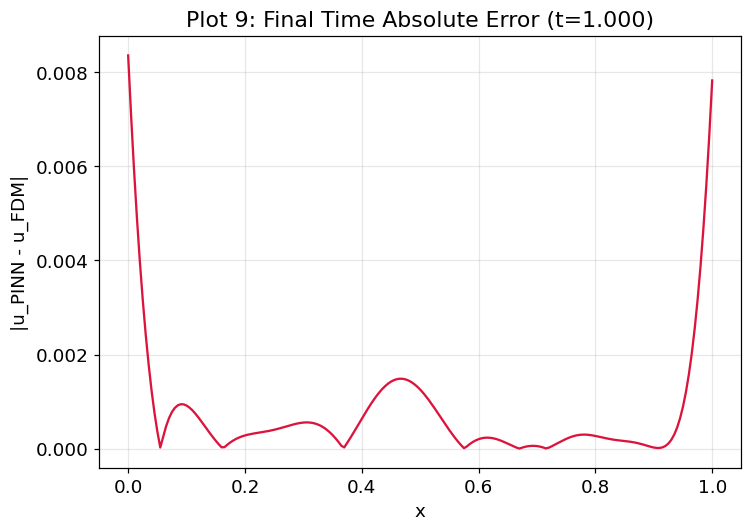

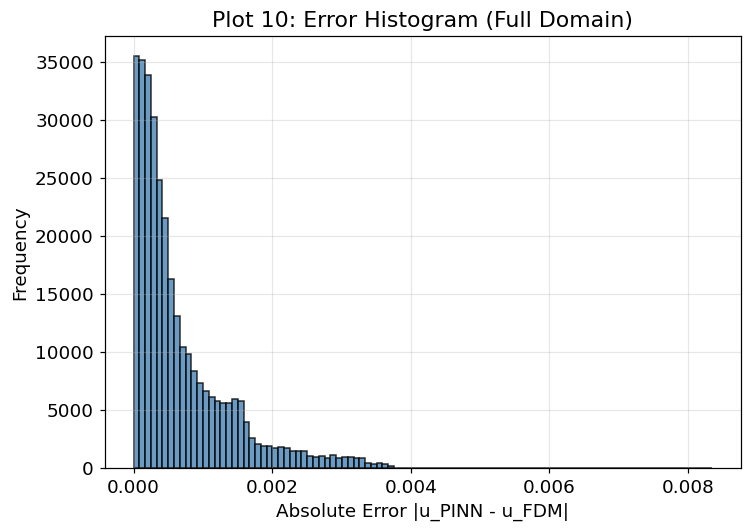

Plots 8-10 saved.


In [14]:
# ============================================================
# CELL 12: Plots 8-10 (Final Time Comparison/Error, Error Histogram)
# ============================================================

final_t_idx = -1  # t = 1 (last row of grid)
final_t_value = t_grid[final_t_idx]

u_fdm_final = U_grid[final_t_idx, :]
u_pinn_final = U_pred_grid[final_t_idx, :]
error_final = np.abs(u_pinn_final - u_fdm_final)

# ---------------------------
# Plot 8: Final Time Comparison
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(x_grid, u_fdm_final, label="FDM (ground truth)", lw=2)
plt.plot(x_grid, u_pinn_final, "--", label="PINN prediction", lw=2)
plt.xlabel("x")
plt.ylabel(f"u(x, t={final_t_value:.3f})")
plt.title(f"Plot 8: Final Time Comparison (t={final_t_value:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot8_final_time_comparison.png", dpi=150)
plt.show()

# ---------------------------
# Plot 9: Final Time Error Plot
# ---------------------------
plt.figure(figsize=(7, 5))
plt.plot(x_grid, error_final, color="crimson", lw=1.5)
plt.xlabel("x")
plt.ylabel("|u_PINN - u_FDM|")
plt.title(f"Plot 9: Final Time Absolute Error (t={final_t_value:.3f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot9_final_time_error.png", dpi=150)
plt.show()

# ---------------------------
# Plot 10: Error Histogram (over full grid)
# ---------------------------
plt.figure(figsize=(7, 5))
plt.hist(Abs_Error_grid.flatten(), bins=100, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel("Absolute Error |u_PINN - u_FDM|")
plt.ylabel("Frequency")
plt.title("Plot 10: Error Histogram (Full Domain)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/plot10_error_histogram.png", dpi=150)
plt.show()

print("Plots 8-10 saved.")


In [15]:
# ============================================================
# CELL 13: Final Metrics Report
# ============================================================

# ---------------------------
# Parameter recovery metrics
# ---------------------------
r_recovered = model.r.item()
r_relative_error_pct = abs(r_recovered - r_true) / r_true * 100.0

# ---------------------------
# Field-wise error metrics (over full Nx x Nt grid)
# ---------------------------
error_field = U_pred_grid - U_grid          # signed error
abs_error_field = np.abs(error_field)

RMSE = np.sqrt(np.mean(error_field**2))
MAE = np.mean(abs_error_field)
Relative_L2 = np.linalg.norm(error_field) / np.linalg.norm(U_grid)
Max_Abs_Error = np.max(abs_error_field)
Mean_Error = np.mean(error_field)
Std_Error = np.std(error_field)

# ---------------------------
# Print formatted report
# ---------------------------
print("=" * 60)
print("FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case II)")
print("=" * 60)
print(f"{'True r':<30}: {r_true:.6f}")
print(f"{'Recovered r':<30}: {r_recovered:.6f}")
print(f"{'Relative Error in r (%)':<30}: {r_relative_error_pct:.6f}")
print("-" * 60)
print(f"{'RMSE':<30}: {RMSE:.6e}")
print(f"{'MAE':<30}: {MAE:.6e}")
print(f"{'Relative L2 Error':<30}: {Relative_L2:.6e}")
print(f"{'Maximum Absolute Error':<30}: {Max_Abs_Error:.6e}")
print(f"{'Mean Error':<30}: {Mean_Error:.6e}")
print(f"{'Standard Deviation of Error':<30}: {Std_Error:.6e}")
print("=" * 60)
print(f"Best epoch (restored model): {best_epoch + 1}")
print(f"Total epochs run: {epoch + 1}")
print("=" * 60)

# ---------------------------
# Save metrics to CSV for reference
# ---------------------------
metrics_dict = {
    "true_r": [r_true],
    "recovered_r": [r_recovered],
    "relative_error_r_pct": [r_relative_error_pct],
    "RMSE": [RMSE],
    "MAE": [MAE],
    "Relative_L2_Error": [Relative_L2],
    "Max_Abs_Error": [Max_Abs_Error],
    "Mean_Error": [Mean_Error],
    "Std_Error": [Std_Error],
    "best_epoch": [best_epoch + 1],
    "total_epochs_run": [epoch + 1]
}
metrics_df = pd.DataFrame(metrics_dict)
metrics_df.to_csv("/content/final_metrics_report.csv", index=False)
print("\nMetrics saved to /content/final_metrics_report.csv")

FINAL METRICS REPORT — Inverse PINN (Fisher-KPP, Case II)
True r                        : 1.000000
Recovered r                   : 0.998829
Relative Error in r (%)       : 0.117058
------------------------------------------------------------
RMSE                          : 1.007228e-03
MAE                           : 6.876713e-04
Relative L2 Error             : 2.387595e-03
Maximum Absolute Error        : 8.355268e-03
Mean Error                    : -1.815508e-04
Standard Deviation of Error   : 9.907304e-04
Best epoch (restored model): 11942
Total epochs run: 12000

Metrics saved to /content/final_metrics_report.csv


In [16]:
# ============================================================
# CELL 14: Overfitting Check — Train vs Full-Grid Error Comparison
# ============================================================

model.eval()

# ---------------------------
# Predictions AT the original training points (8000 points used in training)
# ---------------------------
with torch.no_grad():
    u_pred_train = model(x_train_t, t_train_t).cpu().numpy()
    u_pred_val   = model(x_val_t, t_val_t).cpu().numpy()

u_true_train = u_train_t.cpu().numpy()
u_true_val   = u_val_t.cpu().numpy()

def compute_metrics(u_pred, u_true, label):
    err = u_pred - u_true
    rmse = np.sqrt(np.mean(err**2))
    mae = np.mean(np.abs(err))
    rel_l2 = np.linalg.norm(err) / np.linalg.norm(u_true)
    max_err = np.max(np.abs(err))
    print(f"{label:<35} RMSE={rmse:.6e}  MAE={mae:.6e}  RelL2={rel_l2:.6e}  MaxErr={max_err:.6e}")
    return rmse, mae, rel_l2, max_err

print("=" * 100)
print("OVERFITTING CHECK: Error on Training Points vs Validation Points vs FULL Grid")
print("=" * 100)

train_metrics = compute_metrics(u_pred_train, u_true_train, "Training points (N=8000, SEEN):")
val_metrics   = compute_metrics(u_pred_val,   u_true_val,   "Validation points (N=2000, SEEN in val loss):")

# Full grid error (already computed in Cell 10/13, recomputed here cleanly)
full_err = U_pred_grid - U_grid
full_rmse = np.sqrt(np.mean(full_err**2))
full_mae = np.mean(np.abs(full_err))
full_rel_l2 = np.linalg.norm(full_err) / np.linalg.norm(U_grid)
full_max_err = np.max(np.abs(full_err))
print(f"{'Full grid (N=321600, mostly UNSEEN):':<35} RMSE={full_rmse:.6e}  MAE={full_mae:.6e}  RelL2={full_rel_l2:.6e}  MaxErr={full_max_err:.6e}")

print("=" * 100)
gap_ratio = full_rel_l2 / train_metrics[2]
print(f"\nGeneralization gap ratio (Full RelL2 / Train RelL2): {gap_ratio:.3f}")
print("Interpretation: ratio close to 1.0 => no meaningful overfitting.")
print("Ratio >> 1 (e.g. >3-5x) would indicate the model fits seen points much better than unseen ones.")

OVERFITTING CHECK: Error on Training Points vs Validation Points vs FULL Grid
Training points (N=8000, SEEN):     RMSE=1.018523e-03  MAE=7.019337e-04  RelL2=2.438329e-03  MaxErr=6.443372e-03
Validation points (N=2000, SEEN in val loss): RMSE=9.872814e-04  MAE=6.786411e-04  RelL2=2.308188e-03  MaxErr=6.895922e-03
Full grid (N=321600, mostly UNSEEN): RMSE=1.007228e-03  MAE=6.876713e-04  RelL2=2.387595e-03  MaxErr=8.355268e-03

Generalization gap ratio (Full RelL2 / Train RelL2): 0.979
Interpretation: ratio close to 1.0 => no meaningful overfitting.
Ratio >> 1 (e.g. >3-5x) would indicate the model fits seen points much better than unseen ones.


In [17]:
# ============================================================
# CELL 15: Data Efficiency / Overfitting Stress Test (N_data=2000)
# ============================================================

def train_pinn_with_ndata(N_data_small, seed=42, epochs=12000, patience=2000,
                            D_known=0.01, r_true=1.0, verbose_every=1000):
    """
    Re-runs the full pipeline (fresh model, fresh data sample) with a smaller
    N_data to test data efficiency / overfitting sensitivity.
    Reuses the SAME collocation/IC/BC tensors already defined globally.
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Sample smaller data subset
    data_sample_small = df.sample(n=N_data_small, random_state=seed).reset_index(drop=True)
    X_small = data_sample_small[["x", "t"]].values
    U_small = data_sample_small[["u"]].values

    X_tr, X_va, U_tr, U_va = train_test_split(X_small, U_small, test_size=0.20, random_state=seed)

    x_tr = torch.tensor(X_tr[:, 0:1], dtype=torch.float32, device=device)
    t_tr = torch.tensor(X_tr[:, 1:2], dtype=torch.float32, device=device)
    u_tr = torch.tensor(U_tr, dtype=torch.float32, device=device)

    x_va = torch.tensor(X_va[:, 0:1], dtype=torch.float32, device=device)
    t_va = torch.tensor(X_va[:, 1:2], dtype=torch.float32, device=device)
    u_va = torch.tensor(U_va, dtype=torch.float32, device=device)

    # Fresh model
    model_small = PINN(layers=[2, 50, 50, 50, 50, 50, 50, 50, 1]).to(device)

    network_params_small = []
    for layer in model_small.linears:
        network_params_small += list(layer.parameters())
    optimizer_small = torch.optim.Adam([
        {"params": network_params_small, "lr": 1e-3},
        {"params": [model_small.logr], "lr": 5e-4}
    ])

    best_val = float("inf")
    best_state = None
    best_ep = -1
    patience_ctr = 0
    r_hist = []

    for ep in range(epochs):
        model_small.train()
        optimizer_small.zero_grad()
        Lt, _, _, _, _ = total_loss(
            model_small, x_tr, t_tr, u_tr,
            x_f_t, t_f_t, x_ic_t, t_ic_t, u_ic_target_t,
            x_left_t, x_right_t, t_bc_t, u_bc_target_t, D=D_known
        )
        Lt.backward()
        optimizer_small.step()

        model_small.eval()
        Lv, _, _, _, _ = total_loss(
            model_small, x_va, t_va, u_va,
            x_f_t, t_f_t, x_ic_t, t_ic_t, u_ic_target_t,
            x_left_t, x_right_t, t_bc_t, u_bc_target_t, D=D_known
        )

        r_hist.append(model_small.r.item())

        if Lv.item() < best_val - 1e-8:
            best_val = Lv.item()
            best_ep = ep
            best_state = copy.deepcopy(model_small.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if (ep + 1) % verbose_every == 0:
            print(f"  [N_data={N_data_small}] Epoch {ep+1}/{epochs} | "
                  f"Val Loss: {Lv.item():.4e} | r={model_small.r.item():.5f} | Patience {patience_ctr}/{patience}")

        if patience_ctr >= patience:
            print(f"  [N_data={N_data_small}] Early stopped at epoch {ep+1} (best epoch {best_ep+1})")
            break

    model_small.load_state_dict(best_state)
    model_small.eval()
    r_final_small = model_small.r.item()
    r_err_small = abs(r_final_small - r_true) / r_true * 100.0
    print(f"  [N_data={N_data_small}] FINAL: r={r_final_small:.5f}, error={r_err_small:.4f}%\n")
    return model_small, r_final_small, r_err_small, r_hist


print("Running data-efficiency stress test with N_data=2000 (vs original N_data=10000)...\n")
model_2000, r_2000, r_err_2000, r_hist_2000 = train_pinn_with_ndata(N_data_small=2000, seed=42)

print("=" * 70)
print("DATA EFFICIENCY COMPARISON")
print("=" * 70)
print(f"{'N_data=10000 (original)':<30} r={r_final:.5f}  error={abs(r_final-1.0)*100:.4f}%")
print(f"{'N_data=2000 (stress test)':<30} r={r_2000:.5f}  error={r_err_2000:.4f}%")
print("=" * 70)
print("If r_err_2000 is only modestly worse (not wildly different/unstable),")
print("the PDE constraint is doing real work and the model is NOT just memorizing data.")

Running data-efficiency stress test with N_data=2000 (vs original N_data=10000)...

  [N_data=2000] Epoch 1000/12000 | Val Loss: 3.9634e-03 | r=0.96847 | Patience 0/2000
  [N_data=2000] Epoch 2000/12000 | Val Loss: 4.6414e-03 | r=0.98964 | Patience 2/2000
  [N_data=2000] Epoch 3000/12000 | Val Loss: 6.7236e-04 | r=0.99077 | Patience 92/2000
  [N_data=2000] Epoch 4000/12000 | Val Loss: 5.2030e-04 | r=0.99185 | Patience 0/2000
  [N_data=2000] Epoch 5000/12000 | Val Loss: 4.7648e-04 | r=0.99204 | Patience 1/2000
  [N_data=2000] Epoch 6000/12000 | Val Loss: 4.3281e-04 | r=0.99238 | Patience 0/2000
  [N_data=2000] Epoch 7000/12000 | Val Loss: 4.1731e-04 | r=0.99431 | Patience 118/2000
  [N_data=2000] Epoch 8000/12000 | Val Loss: 3.7485e-04 | r=0.99576 | Patience 161/2000
  [N_data=2000] Epoch 9000/12000 | Val Loss: 3.5087e-04 | r=0.99302 | Patience 128/2000
  [N_data=2000] Epoch 10000/12000 | Val Loss: 3.1527e-04 | r=0.99574 | Patience 120/2000
  [N_data=2000] Epoch 11000/12000 | Val Loss: 

In [18]:
# ============================================================
# CELL 16: Load and Verify r=2 Dataset (Independent Test Set)
# ============================================================

DATA2_FILENAME = "FisherKPP_Inverse_PINN_Dataset2.csv"  # rename your uploaded file to this in Colab
DATA2_PATH = f"/content/{DATA2_FILENAME}"

if not os.path.exists(DATA2_PATH):
    print(f"Please upload the r=2 dataset as: {DATA2_FILENAME}")
    uploaded2 = files.upload()
    uploaded2_name = list(uploaded2.keys())[0]
    if uploaded2_name != DATA2_FILENAME:
        os.rename(uploaded2_name, DATA2_PATH)

df_r2 = pd.read_csv(DATA2_PATH)
print("Raw data shape:", df_r2.shape)

# ---------------------------
# Detect grid size dynamically (this dataset uses Nt=3200, not 1600)
# ---------------------------
x_grid_2 = np.sort(df_r2["x"].unique())
t_grid_2 = np.sort(df_r2["t"].unique())
Nx_2 = len(x_grid_2)
Nt_2 = len(t_grid_2)
print(f"Detected grid: Nx={Nx_2}, Nt={Nt_2}")

df_r2_sorted = df_r2.sort_values(by=["t", "x"]).reset_index(drop=True)
U_grid_2 = df_r2_sorted["u"].values.reshape(Nt_2, Nx_2)

# ---------------------------
# IC verification (Gaussian-only form, consistent with original dataset)
# ---------------------------
u_ic_fdm_2 = U_grid_2[0, :]
u_ic_analytical_2 = np.exp(-50 * (x_grid_2 - 0.5)**2)
ic_max_diff_2 = np.max(np.abs(u_ic_fdm_2 - u_ic_analytical_2))
print(f"Max |FDM IC - Analytical IC| at t=0: {ic_max_diff_2:.3e}")

# ---------------------------
# BC verification
# ---------------------------
print(f"Max |u(0,t)|: {np.max(np.abs(U_grid_2[:, 0])):.3e}")
print(f"Max |u(1,t)|: {np.max(np.abs(U_grid_2[:, -1])):.3e}")

# ---------------------------
# Coverage check: confirm dynamics actually exist (not all-zero like before)
# ---------------------------
nonzero_frac = (df_r2["u"] != 0).mean()
print(f"Fraction of nonzero u values: {nonzero_frac:.4f}")
assert nonzero_frac > 0.5, "Dataset appears mostly zero -- check FDM generation again."

print("\nr=2 dataset verified successfully.")

Please upload the r=2 dataset as: FisherKPP_Inverse_PINN_Dataset2.csv


Saving FisherKPP_Inverse_PINN_Dataset2 (2).csv to FisherKPP_Inverse_PINN_Dataset2 (2).csv
Raw data shape: (643200, 3)
Detected grid: Nx=201, Nt=3200
Max |FDM IC - Analytical IC| at t=0: 3.727e-06
Max |u(0,t)|: 0.000e+00
Max |u(1,t)|: 0.000e+00
Fraction of nonzero u values: 0.9900

r=2 dataset verified successfully.


In [19]:
# ============================================================
# CELL 17: Train Fresh PINN on r=2 Dataset (Identical Pipeline)
# ============================================================

r_true_2 = 2.0
D_known = 0.01

# ---------------------------
# Resample all four point sets from the r=2 dataset
# (same counts/strategy as original: N_data=10000, N_f=10000, N_ic=200, N_bc=200)
# ---------------------------
np.random.seed(42)

N_data = 10000
data_sample_2 = df_r2.sample(n=N_data, random_state=42).reset_index(drop=True)
X_data_2 = data_sample_2[["x", "t"]].values
U_data_2 = data_sample_2[["u"]].values

X_train_2, X_val_2, U_train_2, U_val_2 = train_test_split(
    X_data_2, U_data_2, test_size=0.20, random_state=42
)

x_train_2 = torch.tensor(X_train_2[:, 0:1], dtype=torch.float32, device=device)
t_train_2 = torch.tensor(X_train_2[:, 1:2], dtype=torch.float32, device=device)
u_train_2 = torch.tensor(U_train_2, dtype=torch.float32, device=device)

x_val_2 = torch.tensor(X_val_2[:, 0:1], dtype=torch.float32, device=device)
t_val_2 = torch.tensor(X_val_2[:, 1:2], dtype=torch.float32, device=device)
u_val_2 = torch.tensor(U_val_2, dtype=torch.float32, device=device)

N_f = 10000
x_f_2 = np.random.uniform(0, 1, (N_f, 1))
t_f_2 = np.random.uniform(1e-4, 1, (N_f, 1))
x_f_2_t = torch.tensor(x_f_2, dtype=torch.float32, device=device, requires_grad=True)
t_f_2_t = torch.tensor(t_f_2, dtype=torch.float32, device=device, requires_grad=True)

N_ic = 200
x_ic_2 = np.linspace(0, 1, N_ic).reshape(-1, 1)
t_ic_2 = np.zeros_like(x_ic_2)
u_ic_target_2 = np.exp(-50 * (x_ic_2 - 0.5)**2)
x_ic_2_t = torch.tensor(x_ic_2, dtype=torch.float32, device=device)
t_ic_2_t = torch.tensor(t_ic_2, dtype=torch.float32, device=device)
u_ic_target_2_t = torch.tensor(u_ic_target_2, dtype=torch.float32, device=device)

N_bc = 200
t_bc_2 = np.random.uniform(0, 1, (N_bc, 1))
x_left_2 = np.zeros_like(t_bc_2)
x_right_2 = np.ones_like(t_bc_2)
x_left_2_t = torch.tensor(x_left_2, dtype=torch.float32, device=device)
x_right_2_t = torch.tensor(x_right_2, dtype=torch.float32, device=device)
t_bc_2_t = torch.tensor(t_bc_2, dtype=torch.float32, device=device)
u_bc_target_2_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

print(f"r=2 dataset training tensors prepared: "
      f"{x_train_2.shape[0]} train, {x_val_2.shape[0]} val, "
      f"{N_f} collocation, {N_ic} IC, {N_bc} BC")

# ---------------------------
# Fresh model, identical architecture/optimizer/hyperparameters
# ---------------------------
model_r2 = PINN(layers=[2, 50, 50, 50, 50, 50, 50, 50, 1]).to(device)

network_params_r2 = []
for layer in model_r2.linears:
    network_params_r2 += list(layer.parameters())

optimizer_r2 = torch.optim.Adam([
    {"params": network_params_r2, "lr": 1e-3},
    {"params": [model_r2.logr], "lr": 5e-4}
])

EPOCHS = 12000
PATIENCE = 2000
MIN_DELTA = 1e-8

history_r2 = {
    "train_total": [], "val_total": [], "r": [], "r_error_pct": []
}

best_val_loss_r2 = float("inf")
best_epoch_r2 = -1
best_model_state_r2 = None
patience_counter_r2 = 0

start_time = time.time()

for epoch in range(EPOCHS):
    model_r2.train()
    optimizer_r2.zero_grad()

    L_total, L_data, L_pde, L_ic, L_bc = total_loss(
        model_r2,
        x_train_2, t_train_2, u_train_2,
        x_f_2_t, t_f_2_t,
        x_ic_2_t, t_ic_2_t, u_ic_target_2_t,
        x_left_2_t, x_right_2_t, t_bc_2_t, u_bc_target_2_t,
        D=D_known
    )
    L_total.backward()
    optimizer_r2.step()

    model_r2.eval()
    Lv_total, _, _, _, _ = total_loss(
        model_r2,
        x_val_2, t_val_2, u_val_2,
        x_f_2_t, t_f_2_t,
        x_ic_2_t, t_ic_2_t, u_ic_target_2_t,
        x_left_2_t, x_right_2_t, t_bc_2_t, u_bc_target_2_t,
        D=D_known
    )

    r_current = model_r2.r.item()
    r_err_pct = abs(r_current - r_true_2) / r_true_2 * 100.0

    history_r2["train_total"].append(L_total.item())
    history_r2["val_total"].append(Lv_total.item())
    history_r2["r"].append(r_current)
    history_r2["r_error_pct"].append(r_err_pct)

    current_val = Lv_total.item()
    if current_val < best_val_loss_r2 - MIN_DELTA:
        best_val_loss_r2 = current_val
        best_epoch_r2 = epoch
        best_model_state_r2 = copy.deepcopy(model_r2.state_dict())
        patience_counter_r2 = 0
    else:
        patience_counter_r2 += 1

    if (epoch + 1) % 1000 == 0 or epoch == 0:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1:5d}/{EPOCHS} | Train: {L_total.item():.4e} | "
              f"Val: {current_val:.4e} | r={r_current:.5f} (err {r_err_pct:.4f}%) | "
              f"Patience {patience_counter_r2}/{PATIENCE} | {elapsed:.1f}s")

    if patience_counter_r2 >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best epoch: {best_epoch_r2+1}")
        break

print(f"\nTraining finished in {time.time()-start_time:.1f}s")

model_r2.load_state_dict(best_model_state_r2)
model_r2.eval()

r_final_2 = model_r2.r.item()
print(f"\nBest model restored from epoch {best_epoch_r2+1}")
print(f"Recovered r = {r_final_2:.6f}  (true r = {r_true_2})")
print(f"Relative error = {abs(r_final_2 - r_true_2)/r_true_2*100:.4f}%")

r=2 dataset training tensors prepared: 8000 train, 2000 val, 10000 collocation, 200 IC, 200 BC
Epoch     1/12000 | Train: 1.7980e+01 | Val: 1.3827e+01 | r=0.99950 (err 50.0250%) | Patience 0/2000 | 0.1s
Epoch  1000/12000 | Train: 5.8940e-03 | Val: 5.8208e-03 | r=1.61160 (err 19.4201%) | Patience 0/2000 | 29.0s
Epoch  2000/12000 | Train: 2.5520e-03 | Val: 2.1386e-03 | r=1.94869 (err 2.5657%) | Patience 65/2000 | 55.1s
Epoch  3000/12000 | Train: 1.7234e-03 | Val: 1.6881e-03 | r=1.97929 (err 1.0353%) | Patience 1/2000 | 80.7s
Epoch  4000/12000 | Train: 1.5224e-03 | Val: 1.4881e-03 | r=1.98324 (err 0.8379%) | Patience 0/2000 | 106.7s
Epoch  5000/12000 | Train: 3.2017e-03 | Val: 2.9600e-03 | r=1.98548 (err 0.7262%) | Patience 57/2000 | 132.2s
Epoch  6000/12000 | Train: 1.2235e-03 | Val: 1.1953e-03 | r=1.98820 (err 0.5900%) | Patience 2/2000 | 157.7s
Epoch  7000/12000 | Train: 1.1253e-03 | Val: 1.0825e-03 | r=1.99221 (err 0.3893%) | Patience 106/2000 | 183.5s
Epoch  8000/12000 | Train: 2.888

In [20]:
# ============================================================
# CELL 19: Reusable Function — recover_r_from_dataset()
# ============================================================

def recover_r_from_dataset(
    csv_path,
    D_known=0.01,
    r_true=None,                  # optional, only used for reporting error metrics
    ic_func=None,                 # optional custom IC function; defaults to Gaussian pulse
    N_data=10000,
    N_f=10000,
    N_ic=200,
    N_bc=200,
    layers=[2, 50, 50, 50, 50, 50, 50, 50, 1],
    lr_network=1e-3,
    lr_r=5e-4,
    w_data=100.0,
    w_pde=1.0,
    w_ic=10.0,
    w_bc=10.0,
    epochs=12000,
    patience=2000,
    min_delta=1e-8,
    seed=42,
    verbose_every=1000,
    device=device
):
    """
    End-to-end inverse PINN pipeline: loads an FDM dataset (columns x, t, u),
    trains a PINN to recover the unknown reaction coefficient r in the
    Fisher-KPP equation u_t = D*u_xx + r*u*(1-u), with D fixed/known.

    Returns
    -------
    result : dict containing:
        'model'         : trained PINN (best validation checkpoint restored)
        'r_recovered'   : float, final recovered r
        'r_true'        : float or None, the supplied ground truth (if given)
        'r_rel_error_pct': float or None
        'history'       : dict of per-epoch logs (train/val losses, r, r_error_pct)
        'best_epoch'    : int
        'metrics'       : dict of full-grid RMSE/MAE/RelL2/MaxErr/MeanErr/StdErr
        'grids'         : dict with x_grid, t_grid, U_grid (FDM), U_pred_grid (PINN)
    """
    np.random.seed(seed)
    torch.manual_seed(seed)

    # ---------------------------
    # 1. Load and reshape dataset
    # ---------------------------
    df_local = pd.read_csv(csv_path)
    x_grid_l = np.sort(df_local["x"].unique())
    t_grid_l = np.sort(df_local["t"].unique())
    Nx_l, Nt_l = len(x_grid_l), len(t_grid_l)

    df_sorted_l = df_local.sort_values(by=["t", "x"]).reset_index(drop=True)
    U_grid_l = df_sorted_l["u"].values.reshape(Nt_l, Nx_l)

    nonzero_frac = (df_local["u"] != 0).mean()
    if nonzero_frac < 0.3:
        print(f"WARNING: only {nonzero_frac*100:.1f}% of u values are nonzero. "
              f"Check that this dataset's FDM time-stepping ran correctly.")

    # Default IC: Gaussian pulse (matches validated datasets); override via ic_func if needed
    if ic_func is None:
        ic_func = lambda x: np.exp(-50 * (x - 0.5)**2)

    ic_check = np.max(np.abs(U_grid_l[0, :] - ic_func(x_grid_l)))
    print(f"[{os.path.basename(csv_path)}] Grid: Nx={Nx_l}, Nt={Nt_l} | "
          f"IC max diff: {ic_check:.3e} | nonzero u fraction: {nonzero_frac:.4f}")

    # ---------------------------
    # 2. Sample data / collocation / IC / BC points
    # ---------------------------
    data_sample_l = df_local.sample(n=N_data, random_state=seed).reset_index(drop=True)
    X_data_l = data_sample_l[["x", "t"]].values
    U_data_l = data_sample_l[["u"]].values
    X_tr, X_va, U_tr, U_va = train_test_split(X_data_l, U_data_l, test_size=0.20, random_state=seed)

    x_tr_t = torch.tensor(X_tr[:, 0:1], dtype=torch.float32, device=device)
    t_tr_t = torch.tensor(X_tr[:, 1:2], dtype=torch.float32, device=device)
    u_tr_t = torch.tensor(U_tr, dtype=torch.float32, device=device)
    x_va_t = torch.tensor(X_va[:, 0:1], dtype=torch.float32, device=device)
    t_va_t = torch.tensor(X_va[:, 1:2], dtype=torch.float32, device=device)
    u_va_t = torch.tensor(U_va, dtype=torch.float32, device=device)

    x_f_l = np.random.uniform(0, 1, (N_f, 1))
    t_f_l = np.random.uniform(1e-4, 1, (N_f, 1))
    x_f_t = torch.tensor(x_f_l, dtype=torch.float32, device=device, requires_grad=True)
    t_f_t = torch.tensor(t_f_l, dtype=torch.float32, device=device, requires_grad=True)

    x_ic_l = np.linspace(0, 1, N_ic).reshape(-1, 1)
    t_ic_l = np.zeros_like(x_ic_l)
    u_ic_target_l = ic_func(x_ic_l)
    x_ic_t = torch.tensor(x_ic_l, dtype=torch.float32, device=device)
    t_ic_t = torch.tensor(t_ic_l, dtype=torch.float32, device=device)
    u_ic_target_t = torch.tensor(u_ic_target_l, dtype=torch.float32, device=device)

    t_bc_l = np.random.uniform(0, 1, (N_bc, 1))
    x_left_t = torch.tensor(np.zeros_like(t_bc_l), dtype=torch.float32, device=device)
    x_right_t = torch.tensor(np.ones_like(t_bc_l), dtype=torch.float32, device=device)
    t_bc_t = torch.tensor(t_bc_l, dtype=torch.float32, device=device)
    u_bc_target_t = torch.zeros((N_bc, 1), dtype=torch.float32, device=device)

    # ---------------------------
    # 3. Fresh model + optimizer
    # ---------------------------
    model_l = PINN(layers=layers).to(device)
    network_params_l = []
    for layer in model_l.linears:
        network_params_l += list(layer.parameters())
    optimizer_l = torch.optim.Adam([
        {"params": network_params_l, "lr": lr_network},
        {"params": [model_l.logr], "lr": lr_r}
    ])

    # ---------------------------
    # 4. Training loop with early stopping
    # ---------------------------
    history_l = {"train_total": [], "val_total": [], "r": [], "r_error_pct": []}
    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None
    patience_ctr = 0

    start_time = time.time()
    for epoch in range(epochs):
        model_l.train()
        optimizer_l.zero_grad()
        L_total, *_ = total_loss(
            model_l, x_tr_t, t_tr_t, u_tr_t, x_f_t, t_f_t,
            x_ic_t, t_ic_t, u_ic_target_t, x_left_t, x_right_t, t_bc_t, u_bc_target_t,
            D=D_known, w_data=w_data, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc
        )
        L_total.backward()
        optimizer_l.step()

        model_l.eval()
        Lv_total, *_ = total_loss(
            model_l, x_va_t, t_va_t, u_va_t, x_f_t, t_f_t,
            x_ic_t, t_ic_t, u_ic_target_t, x_left_t, x_right_t, t_bc_t, u_bc_target_t,
            D=D_known, w_data=w_data, w_pde=w_pde, w_ic=w_ic, w_bc=w_bc
        )

        r_current = model_l.r.item()
        r_err_pct = (abs(r_current - r_true) / r_true * 100.0) if r_true is not None else None

        history_l["train_total"].append(L_total.item())
        history_l["val_total"].append(Lv_total.item())
        history_l["r"].append(r_current)
        history_l["r_error_pct"].append(r_err_pct)

        current_val = Lv_total.item()
        if current_val < best_val_loss - min_delta:
            best_val_loss = current_val
            best_epoch = epoch
            best_state = copy.deepcopy(model_l.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if (epoch + 1) % verbose_every == 0 or epoch == 0:
            err_str = f"{r_err_pct:.4f}%" if r_err_pct is not None else "N/A"
            print(f"  Epoch {epoch+1:5d}/{epochs} | Train: {L_total.item():.4e} | "
                  f"Val: {current_val:.4e} | r={r_current:.5f} (err {err_str}) | "
                  f"Patience {patience_ctr}/{patience}")

        if patience_ctr >= patience:
            print(f"  Early stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}")
            break

    print(f"  Training finished in {time.time()-start_time:.1f}s")
    model_l.load_state_dict(best_state)
    model_l.eval()
    r_final_l = model_l.r.item()
    r_rel_err = (abs(r_final_l - r_true) / r_true * 100.0) if r_true is not None else None

    # ---------------------------
    # 5. Full-field inference + metrics
    # ---------------------------
    X_full_l, T_full_l = np.meshgrid(x_grid_l, t_grid_l)
    x_full_flat = X_full_l.reshape(-1, 1)
    t_full_flat = T_full_l.reshape(-1, 1)
    x_full_t = torch.tensor(x_full_flat, dtype=torch.float32, device=device)
    t_full_t = torch.tensor(t_full_flat, dtype=torch.float32, device=device)

    batch_size = 20000
    preds = []
    with torch.no_grad():
        for i in range(0, x_full_t.shape[0], batch_size):
            preds.append(model_l(x_full_t[i:i+batch_size], t_full_t[i:i+batch_size]).cpu().numpy())
    U_pred_grid_l = np.concatenate(preds, axis=0).reshape(Nt_l, Nx_l)

    err_field = U_pred_grid_l - U_grid_l
    metrics = {
        "RMSE": np.sqrt(np.mean(err_field**2)),
        "MAE": np.mean(np.abs(err_field)),
        "Relative_L2": np.linalg.norm(err_field) / np.linalg.norm(U_grid_l),
        "Max_Abs_Error": np.max(np.abs(err_field)),
        "Mean_Error": np.mean(err_field),
        "Std_Error": np.std(err_field),
    }

    print(f"\n  Recovered r = {r_final_l:.6f}" +
          (f"  (true={r_true}, rel error={r_rel_err:.4f}%)" if r_true is not None else ""))
    print(f"  Relative L2 Error (full grid): {metrics['Relative_L2']:.6e}")

    return {
        "model": model_l,
        "r_recovered": r_final_l,
        "r_true": r_true,
        "r_rel_error_pct": r_rel_err,
        "history": history_l,
        "best_epoch": best_epoch,
        "metrics": metrics,
        "grids": {
            "x_grid": x_grid_l, "t_grid": t_grid_l,
            "U_grid": U_grid_l, "U_pred_grid": U_pred_grid_l
        }
    }


print("recover_r_from_dataset() defined and ready to use.")

recover_r_from_dataset() defined and ready to use.


In [21]:
# ============================================================
# CELL 21: Confidence Diagnostics When r_true is UNKNOWN
# ============================================================

def estimate_r_with_confidence(csv_path, D_known=0.01, ic_func=None,
                                  n_seeds=3, seeds=(42, 123, 2024), **kwargs):
    """
    Runs recover_r_from_dataset() across multiple random seeds (no r_true needed)
    and reports the mean/std of recovered r as a practical confidence measure,
    plus the final PDE residual loss as a physics-consistency check.
    """
    results = []
    for i, seed in enumerate(seeds[:n_seeds]):
        print(f"\n--- Run {i+1}/{n_seeds} (seed={seed}) ---")
        res = recover_r_from_dataset(
            csv_path=csv_path, D_known=D_known, r_true=None,
            ic_func=ic_func, seed=seed, **kwargs
        )
        results.append(res)

    r_values = np.array([res["r_recovered"] for res in results])

    print("\n" + "=" * 60)
    print("MULTI-SEED CONFIDENCE REPORT (no ground-truth r available)")
    print("=" * 60)
    for i, r_val in enumerate(r_values):
        print(f"  Seed {seeds[i]}: r = {r_val:.6f}")
    print("-" * 60)
    r_mean = r_values.mean()
    r_std = r_values.std()
    cv_pct = (r_std / r_mean) * 100.0
    print(f"  Mean r:                 {r_mean:.6f}")
    print(f"  Std across seeds:       {r_std:.6f}")
    print(f"  Coefficient of variation: {cv_pct:.4f}%")
    print("=" * 60)

    if cv_pct < 1.0:
        print("✅ Estimate is STABLE across seeds (CV < 1%) -- r is likely well-identified.")
    elif cv_pct < 5.0:
        print("⚠️ Moderate variation across seeds (1-5%) -- treat r with some caution;")
        print("   consider more collocation points or longer training.")
    else:
        print("❌ High variation across seeds (>5%) -- r may be poorly identified from")
        print("   this data; the inverse problem might be under-constrained.")

    # ---------------------------
    # Physics consistency check: final PDE residual using best model from run 1
    # ---------------------------
    best_res = results[0]
    model_check = best_res["model"]
    x_grid_c = best_res["grids"]["x_grid"]
    t_grid_c = best_res["grids"]["t_grid"]

    # Sample fresh collocation points across domain to check residual
    np.random.seed(999)
    x_check = torch.tensor(np.random.uniform(0, 1, (5000, 1)), dtype=torch.float32,
                            device=device, requires_grad=True)
    t_check = torch.tensor(np.random.uniform(1e-4, 1, (5000, 1)), dtype=torch.float32,
                            device=device, requires_grad=True)
    f_check = pde_residual(model_check, x_check, t_check, D=D_known)
    pde_residual_mse = torch.mean(f_check**2).item()

    print(f"\nFinal PDE residual MSE (physics consistency check): {pde_residual_mse:.6e}")
    if pde_residual_mse < 1e-4:
        print("✅ PDE residual is small -- the recovered solution genuinely satisfies the governing equation.")
    else:
        print("⚠️ PDE residual is non-negligible -- recovered r may not fully explain the dynamics;")
        print("   consider increasing w_pde, N_f, or training longer.")

    return {
        "r_mean": r_mean,
        "r_std": r_std,
        "cv_pct": cv_pct,
        "individual_results": results,
        "pde_residual_mse": pde_residual_mse
    }


# ---------------------------
# Example usage for a dataset with UNKNOWN r
# ---------------------------
# confidence_report = estimate_r_with_confidence(
#     csv_path="/content/some_unknown_r_dataset.csv",
#     D_known=0.01,
#     n_seeds=3
# )
# print("\nBest estimate of r:", confidence_report["r_mean"], "+/-", confidence_report["r_std"])

In [25]:
confidence_report = estimate_r_with_confidence(
    csv_path="FisherKPP_Inverse_PINN_Dataset.csv",
    D_known=0.01,
    n_seeds=3
    )
print("\nBest estimate of r:", confidence_report["r_mean"], "+/-", confidence_report["r_std"])


--- Run 1/3 (seed=42) ---
[FisherKPP_Inverse_PINN_Dataset.csv] Grid: Nx=201, Nt=1600 | IC max diff: 3.727e-06 | nonzero u fraction: 0.9900
  Epoch     1/12000 | Train: 3.7708e+01 | Val: 1.6082e+01 | r=0.99950 (err N/A) | Patience 0/2000
  Epoch  1000/12000 | Train: 3.7605e-03 | Val: 3.8142e-03 | r=0.97720 (err N/A) | Patience 0/2000
  Epoch  2000/12000 | Train: 1.1700e-03 | Val: 1.1661e-03 | r=0.99538 (err N/A) | Patience 0/2000
  Epoch  3000/12000 | Train: 4.1243e-02 | Val: 2.4918e-02 | r=0.99361 (err N/A) | Patience 41/2000
  Epoch  4000/12000 | Train: 5.6795e-04 | Val: 5.5993e-04 | r=0.99367 (err N/A) | Patience 118/2000
  Epoch  5000/12000 | Train: 7.3674e-02 | Val: 4.2143e-02 | r=0.99399 (err N/A) | Patience 32/2000
  Epoch  6000/12000 | Train: 4.4750e-04 | Val: 4.4001e-04 | r=0.99431 (err N/A) | Patience 0/2000
  Epoch  7000/12000 | Train: 4.0477e-04 | Val: 3.9818e-04 | r=0.99488 (err N/A) | Patience 255/2000
  Epoch  8000/12000 | Train: 3.9386e-04 | Val: 4.6533e-04 | r=0.99550 